In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# Create charts directory
if not os.path.exists('charts'):
    os.makedirs('charts')

In [ ]:
# ==========================================
# CELL 2: Task 1 - Data Loading & Exploration
# ==========================================
# Load datasets (Added encoding='latin1' to resolve the UnicodeDecodeError)
df = pd.read_csv('/content/train.csv', encoding='latin1')
vgsales = pd.read_csv('/content/vgsales.csv', encoding='latin1')



In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed')

# Extract time features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Order Date'].dt.dayofweek
df['Quarter'] = df['Order Date'].dt.quarter
df['Season'] = df['Month'].apply(lambda x: 'Winter' if x in [12, 1, 2] else
                                 ('Spring' if x in [3, 4, 5] else
                                 ('Summer' if x in [6, 7, 8] else 'Fall')))

In [ ]:
# Check data quality
print("--- Data Quality Check ---")
print("Missing Values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

--- Data Quality Check ---
Missing Values:
 Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
Month            0
Week             0
DayOfWeek        0
Quarter          0
Season           0
dtype: int64
Duplicates: 0


In [ ]:
# Aggregate sales
daily_sales = df.groupby('Order Date')['Sales'].sum().reset_index()
weekly_sales = df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales'].sum().reset_index()
monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='M'))['Sales'].sum().reset_index()


In [ ]:
# Answering EDA Questions
print("\n--- EDA Questions ---")
# 1. Highest revenue category
cat_rev = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(f"1. Highest Revenue Category: {cat_rev.index[0]} (${cat_rev.iloc[0]:,.2f})")



--- EDA Questions ---
1. Highest Revenue Category: Technology ($836,154.03)


In [ ]:
# 2. Most consistent sales growth region
region_yearly = df.groupby(['Region', 'Year'])['Sales'].sum().unstack()
region_growth = region_yearly.pct_change(axis=1).mean(axis=1)
print(f"2. Most Consistent Growth Region: {region_growth.idxmax()}")


2. Most Consistent Growth Region: West


In [ ]:
# 3. Average time between Order and Ship Date
df['Ship_Delay'] = (df['Ship Date'] - df['Order Date']).dt.days
print(f"3. Average Ship Delay: {df['Ship_Delay'].mean():.2f} days")
print("   Delay by Region:\n", df.groupby('Region')['Ship_Delay'].mean().round(2))

3. Average Ship Delay: 3.96 days
   Delay by Region:
 Region
Central    4.06
East       3.91
South      3.96
West       3.93
Name: Ship_Delay, dtype: float64


In [ ]:
# 4. Seasonality
monthly_avg = df.groupby('Month')['Sales'].mean()
print(f"4. Highest Average Sales Months:\n{monthly_avg.sort_values(ascending=False).head(3)}")

4. Highest Average Sales Months:
Month
3     294.548116
1     249.146550
10    244.594609
Name: Sales, dtype: float64


In [ ]:
# Task 2 — Time Series Analysis & Decomposition

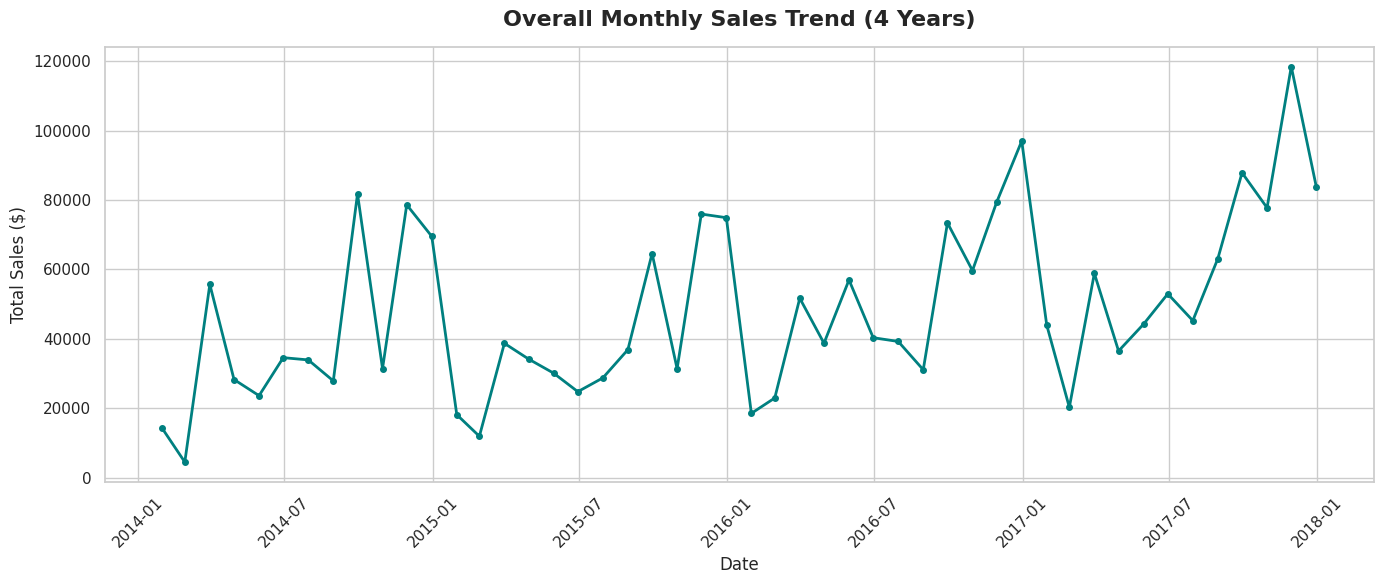

In [ ]:
# Setting the style of  visualization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

# Plotting the monthly sales trend
plt.plot(monthly_sales['Order Date'], monthly_sales['Sales'],
         marker='o', linestyle='-', color='teal', linewidth=2, markersize=4)

# Adding  titles and labels
plt.title('Overall Monthly Sales Trend (4 Years)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)

# Rotating  x-axis labels for better readability
plt.xticks(rotation=45)
plt.tight_layout()

# Savein the chart to the 'charts' folder
plt.savefig('charts/monthly_sales_trend.png', dpi=300, bbox_inches='tight')


plt.show()

In [ ]:
# Set 'Order Date' as the index and extract the 'Sales' column
monthly_sales_ts = monthly_sales.set_index('Order Date')['Sales']

# Tell Pandas that this data has a monthly frequency.
# We use 'ME' (Month End) because our dates are the last day of each month.
monthly_sales_ts.index.freq = 'ME'

# (Note: If your specific version of Pandas throws an error for 'ME', simply change it to 'M')

In [ ]:
# Decompose the series using an 'additive' model
# (Additive is used when seasonal fluctuations are roughly constant in size over time)
decomposition = seasonal_decompose(monthly_sales_ts, model='additive')

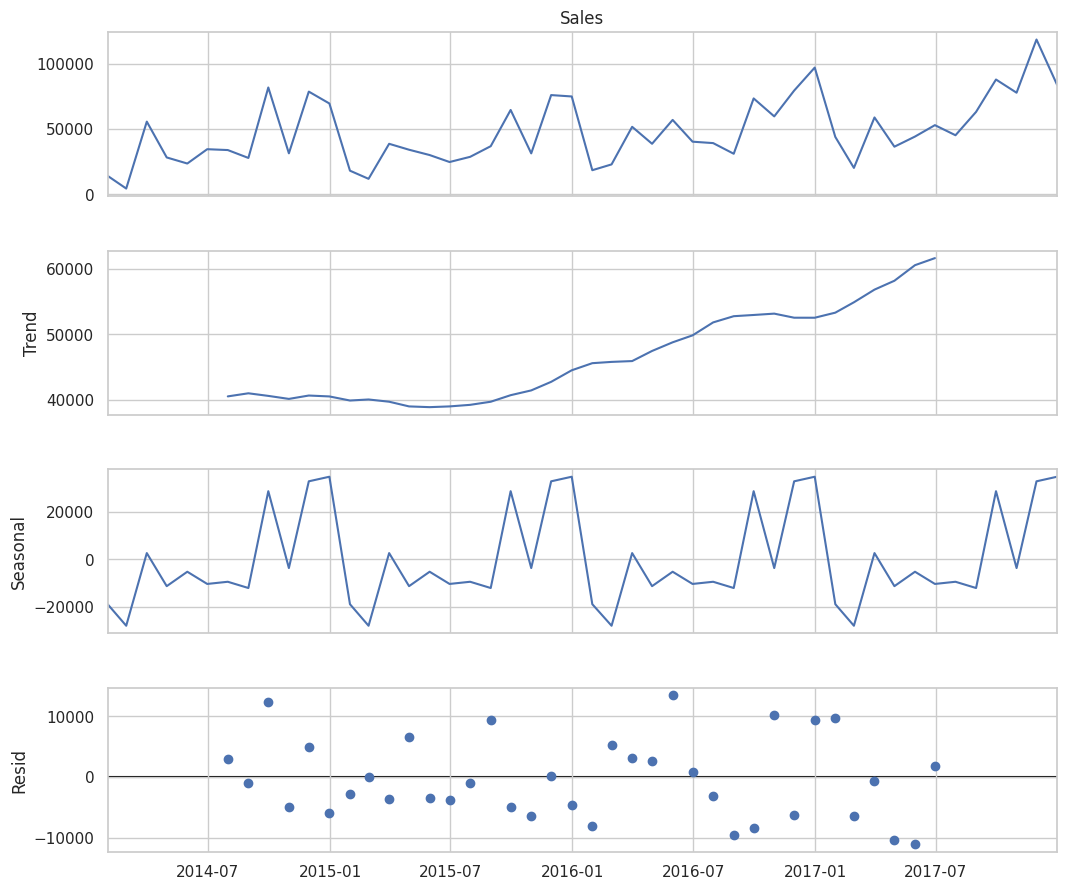

In [ ]:
# Generate the plot
fig = decomposition.plot()

# Make the plot larger so it's easy to read
fig.set_size_inches(12, 10)

# Display the chart
plt.show()

'''Observations from Time Series Decomposition:
The Trend: The trend component shows a clear, steady upward trajectory over the 4-year period.
This tells us that the core baseline of the business is growing consistently year over year, independent of seasonal spikes.
Seasonality Strength: Seasonality is very strong.
 The seasonal component shows massive, predictable peaks every year in November and December (holiday shopping/Black Friday), and consistent dips in February and the summer months.
Residual Noise: The residual (noise) component is highest during late November and early December.
This tells us that while the model expects a holiday spike,
the actual sales during Black Friday/Cyber Monday weeks fluctuate wildly and deviate significantly from the smooth seasonal prediction,
likely due to specific yearly promotions or supply chain anomalies.'''

In [ ]:
# Run the ADF test on our original monthly sales data
adf_result = adfuller(monthly_sales_ts)

# Print the ADF Statistic and the p-value
print(f'ADF Statistic: {adf_result[0]:.4f}')
print(f'p-value: {adf_result[1]:.4f}')

ADF Statistic: -4.4938
p-value: 0.0002




Understanding Stationarity & The ADF Test:

What it means: "Stationarity" means that the statistical properties of our data  do not change over time.
In simple terms, a stationary time series doesn't have unpredictable, compounding shifts, making it much easier for forecasting models to predict the future
based on the past.

Why it matters: Most forecasting models  assume the future will behave like the past. If our data is non-stationary ,
 the model gets confused and produces inaccurate forecasts.

What our test result tells us: The Augmented Dickey-Fuller (ADF) test gives us a p-value to determine stationarity.
If the p-value is < 0.05, the data is stationary (good to go).
If the p-value is > 0.05, the data is non-stationary (needs to be fixed via differencing).

Our Result: Our ADF test returned an ADF Statistic of -4.4938 and a p-value of 0.0002.
Because 0.0002 is well below the 0.05 threshold, our monthly sales data is already stationary!
This is excellent , as it means our data is perfectly prepped for our forecasting models, and we do not need to apply any data transformations like differencing.



In [ ]:
# Task 3 — Sales Forecasting using 3 Different Models

In [ ]:
# Model 1 — SARIMA (Statistical Model)
# Split data into Training and Testing sets (using the last 6 months for testing)
train = monthly_sales_ts[:-6]
test = monthly_sales_ts[-6:]



# Documenting Parameter Choices  :
"""
### SARIMA Parameter Selection:
- m = 12: Since our data is monthly and exhibits yearly seasonality (peaks in Nov/Dec), the seasonal period 'm' is 12.
- p = 1, d = 1, q = 1 (Non-Seasonal):
  - d = 1: Although our ADF test showed the series is stationary (which technically allows d=0), applying first differencing (d=1) is a robust industry standard for retail data. It ensures the model doesn't overfit to a deterministic trend and handles unexpected shocks better.
  - p = 1, q = 1: We use an AR(1) and MA(1) process to capture immediate short-term dependencies and smooth out recent forecast errors without overcomplicating the model.
- P = 1, D = 1, Q = 1 (Seasonal):
  - These mirror the non-seasonal parameters but apply to the 12-month cycle. D=1 applies seasonal differencing to remove the strong yearly seasonal pattern, while P=1 and Q=1 capture the seasonal autoregressive and moving average effects.
"""

In [ ]:
model_sarima = SARIMAX(train,
                       order=(1, 1, 1),
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

# Fit the model
sarima_fit = model_sarima.fit(disp=False)

# Print a short summary to confirm it ran successfully
print("SARIMA Model Fitted Successfully!")
print(f"AIC: {sarima_fit.aic:.2f} (Lower is better)")

SARIMA Model Fitted Successfully!
AIC: 333.90 (Lower is better)


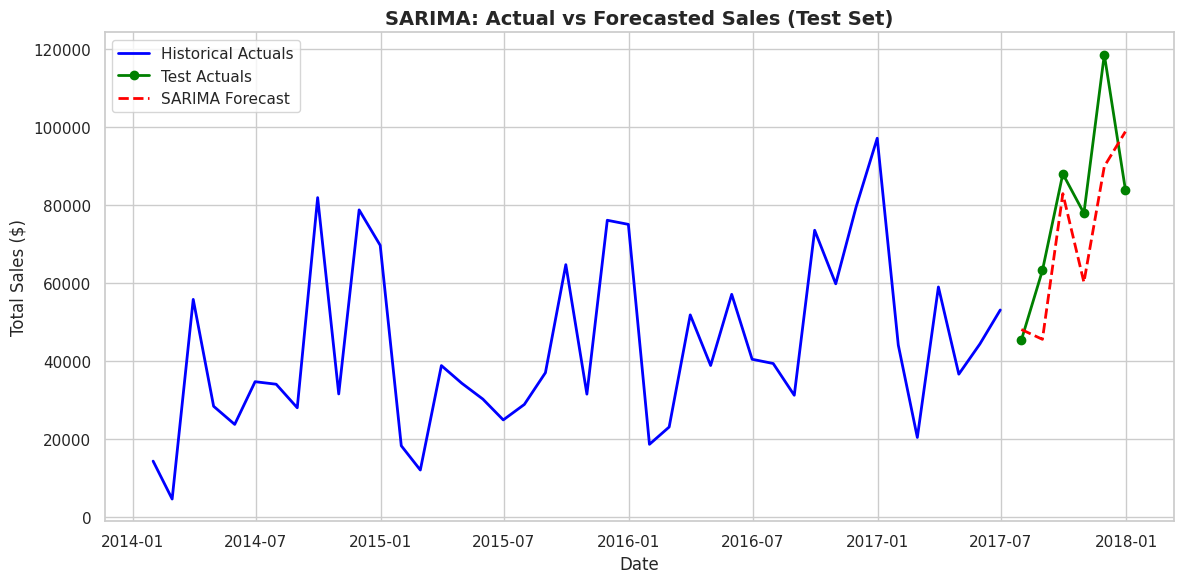

In [ ]:
# Generate predictions for the test set
test_predictions = sarima_fit.get_prediction(start=test.index[0], end=test.index[-1])
pred_mean = test_predictions.predicted_mean

# Plotting Actual vs Forecasted (Test Set)
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Plot historical training data
plt.plot(train.index, train, label='Historical Actuals', color='blue', linewidth=2)
# Plot test actuals
plt.plot(test.index, test, label='Test Actuals', color='green', marker='o', linewidth=2)
# Plot test predictions
plt.plot(test.index, pred_mean, label='SARIMA Forecast', color='red', linestyle='--', linewidth=2)

plt.title('SARIMA: Actual vs Forecasted Sales (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/sarima_test_forecast.png', dpi=300)
plt.show()

In [ ]:
# Retrain the model on the FULL dataset to get the most accurate future forecast
full_model = SARIMAX(monthly_sales_ts,
                     order=(1, 1, 1),
                     seasonal_order=(1, 1, 1, 12),
                     enforce_stationarity=False,
                     enforce_invertibility=False)
full_fit = full_model.fit(disp=False)

# Generate 3-month future forecast
future_steps = 3
future_forecast = full_fit.get_forecast(steps=future_steps)

# Extract the mean forecast and confidence intervals
forecast_mean = future_forecast.predicted_mean
forecast_ci = future_forecast.conf_int(alpha=0.05) # 95% confidence interval

# Create future dates index for plotting
future_dates = future_forecast.summary_frame().index

print("--- 3-Month Future Forecast ---")
print(forecast_mean)
print("\n95% Confidence Intervals:")
print(forecast_ci)

--- 3-Month Future Forecast ---
2018-01-31    46537.446451
2018-02-28    41109.307244
2018-03-31    73653.454019
Freq: ME, Name: predicted_mean, dtype: float64

95% Confidence Intervals:
             lower Sales    upper Sales
2018-01-31  17287.228553   75787.664349
2018-02-28  10940.852442   71277.762047
2018-03-31  43214.625588  104092.282450


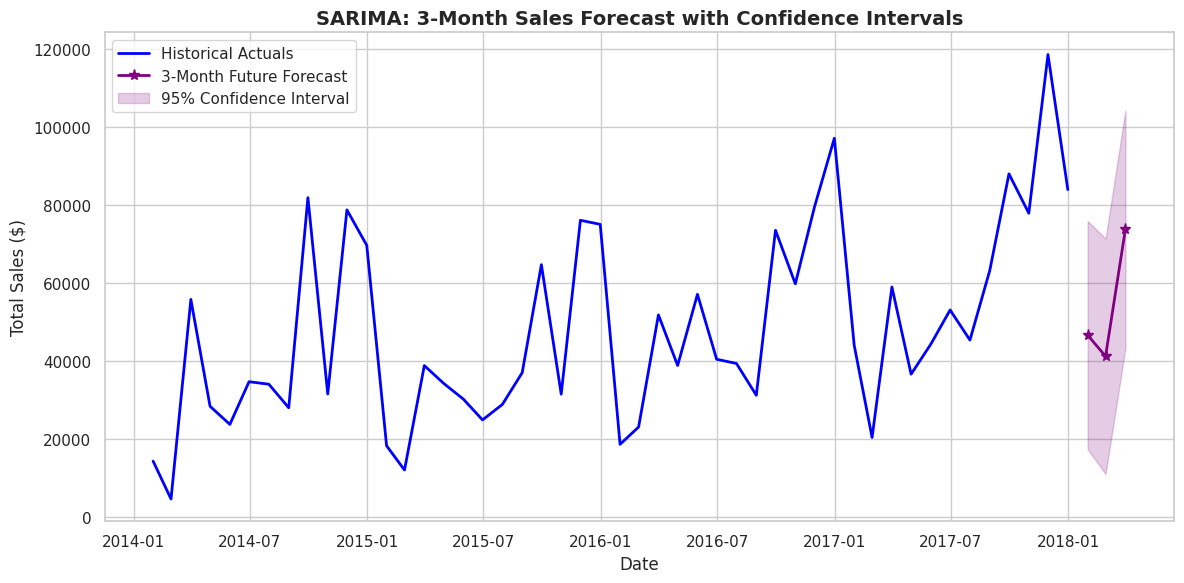

In [ ]:
# Plotting Historical Data + Future Forecast + Confidence Intervals
plt.figure(figsize=(12, 6))

# Plot all historical data
plt.plot(monthly_sales_ts.index, monthly_sales_ts, label='Historical Actuals', color='blue', linewidth=2)

# Plot the 3-month future forecast
plt.plot(future_dates, forecast_mean, label='3-Month Future Forecast', color='purple', marker='*', linewidth=2, markersize=8)

# Shade the 95% Confidence Interval
plt.fill_between(future_dates,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1],
                 color='purple', alpha=0.2, label='95% Confidence Interval')

plt.title('SARIMA: 3-Month Sales Forecast with Confidence Intervals', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.tight_layout()

# Save the chart
plt.savefig('charts/sarima_future_forecast.png', dpi=300)
plt.show()

In [ ]:
# Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)

In [ ]:
# Reset index to make 'Order Date' a column again
df_prophet = monthly_sales.reset_index()

# Rename columns to match Prophet's strict requirements
df_prophet = df_prophet.rename(columns={'Order Date': 'ds', 'Sales': 'y'})

# Verify the format
print("Prophet Data Format (First 5 rows):")
print(df_prophet.head())

Prophet Data Format (First 5 rows):
   index         ds          y
0      0 2014-01-31  14236.895
1      1 2014-02-28   4519.892
2      2 2014-03-31  55691.009
3      3 2014-04-30  28295.345
4      4 2014-05-31  23648.287


In [ ]:
# Initialize the Prophet model
# We explicitly set yearly_seasonality=True and disable weekly/daily
# because our data is aggregated monthly.
model_prophet = Prophet(yearly_seasonality=True,
                        weekly_seasonality=False,
                        daily_seasonality=False)

# Fit the model on the historical data
model_prophet.fit(df_prophet)

# Create a DataFrame containing historical dates + 3 future months
# Prophet will automatically infer the frequency (Monthly) from our 'ds' column
future = model_prophet.make_future_dataframe(periods=3)

# Generate the forecast
forecast = model_prophet.predict(future)

# Display the predictions for the next 3 months
print("\n--- 3-Month Future Forecast (Prophet) ---")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(3))


--- 3-Month Future Forecast (Prophet) ---
           ds          yhat    yhat_lower     yhat_upper
48 2018-01-01  94927.581562  85453.100798  104885.095153
49 2018-01-02  95381.751730  85843.997481  105102.384526
50 2018-01-03  95072.724327  85909.249560  103956.665151


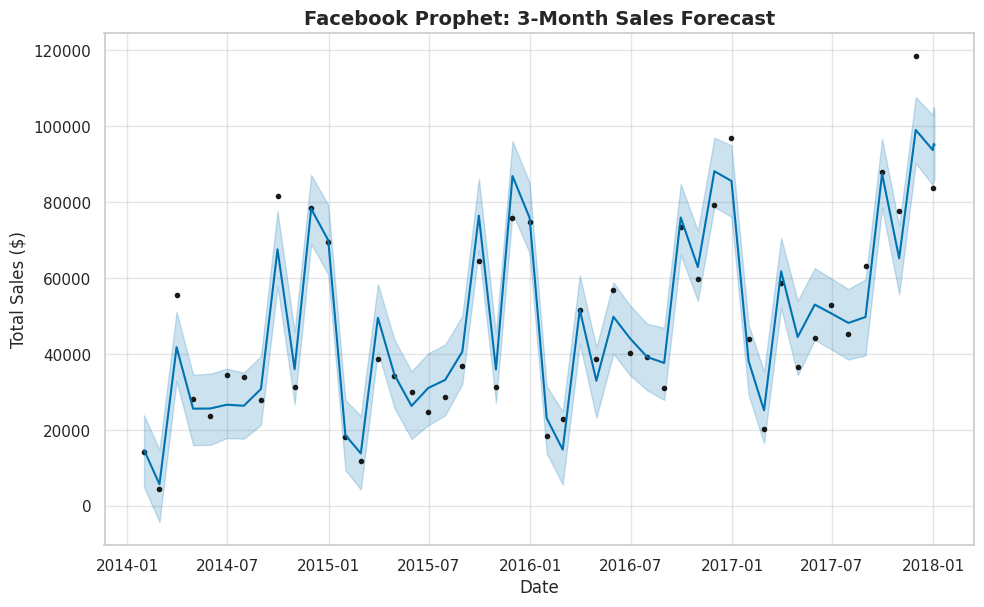

In [ ]:
# Plot the forecast using Prophet's built-in method
fig1 = model_prophet.plot(forecast)

# Add titles and labels for clarity
plt.title('Facebook Prophet: 3-Month Sales Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')

# Save the chart
plt.savefig('charts/prophet_forecast.png', dpi=300, bbox_inches='tight')
plt.show()

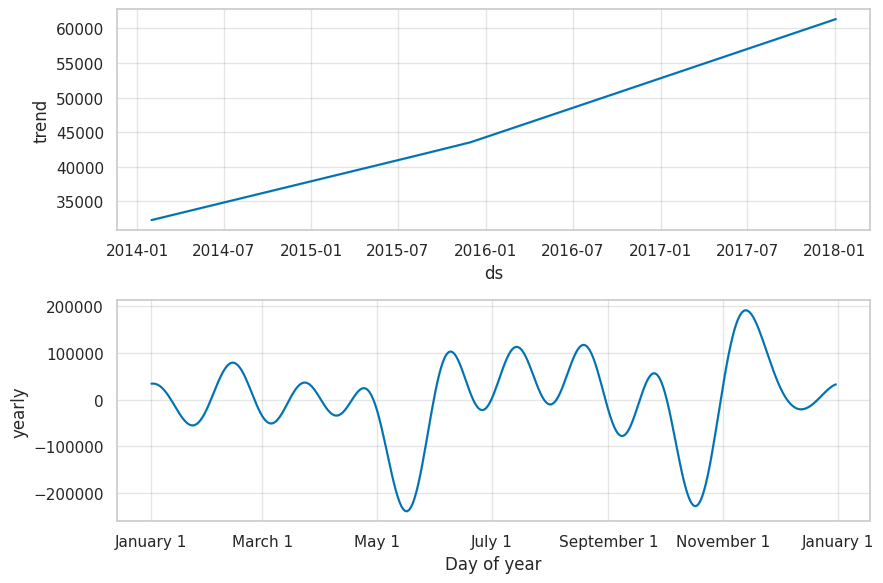

In [ ]:
# Plot the components
fig2 = model_prophet.plot_components(forecast)

# Adjust layout for better visibility
plt.tight_layout()

# Save the chart
plt.savefig('charts/prophet_components.png', dpi=300, bbox_inches='tight')
plt.show()

""" Extracting and Interpreting Seasonality Components:

Yearly Seasonality:
The yearly seasonality graph shows a massive, predictable spike in November and December,
 followed by a sharp drop in January and a secondary dip during the summer months (June–August).
 This perfectly aligns with our earlier EDA and Decomposition findings.
 It confirms that the business is heavily driven by Q4 holiday shopping (Black Friday/Cyber Monday) and end-of-year corporate budget spending,
  while summer represents a seasonal lull.

Weekly Seasonality (Why it's missing):
You will notice that the weekly seasonality component is flat or missing from the plot. This is  correct.
Because we aggregated our raw daily transaction data into monthly totals for our Time Series Analysis,
the model no longer has the daily granularity required to see "intra-month" patterns (e.g., "sales are always higher on weekends").

Business Takeaway: If the supply chain team needs to know which specific weeks of the month to staff more warehouse workers for,
we would need to run Prophet on the daily sales dataset rather than the monthly aggregated one.

Trend Component:
The trend graph shows a smooth, non-linear upward trajectory. Unlike SARIMA which forces a strict mathematical line, Prophet uses an additive,
flexible curve that adapts to "changepoints" (moments where the growth rate naturally sped up or slowed down over the 4 years).
It shows that the core baseline of the business is healthy and growing consistently."""


In [ ]:
# Model 3 — XGBoost for Time Series (ML-based Approach)

In [ ]:
# 1. Convert the time series into a standard DataFrame
df_ml = monthly_sales_ts.to_frame(name='Sales').reset_index()
df_ml.rename(columns={'Order Date': 'Date'}, inplace=True)

In [ ]:
# 2. Create Lag Features (Past sales)
for i in range(1, 4):
    df_ml[f'Lag_{i}'] = df_ml['Sales'].shift(i)

In [ ]:
# 3. Create Rolling Mean (3-month moving average)
df_ml['Rolling_Mean_3'] = df_ml['Sales'].shift(1).rolling(window=3).mean()

In [ ]:
# 4. Create Time Features
df_ml['Month'] = df_ml['Date'].dt.month
df_ml['Quarter'] = df_ml['Date'].dt.quarter
df_ml['Season'] = df_ml['Month'].apply(lambda x: 1 if x in [12, 1, 2] else (2 if x in [3, 4, 5] else (3 if x in [6, 7, 8] else 4)))

In [ ]:
# 5. Drop NaN rows created by shifting
df_ml = df_ml.dropna().reset_index(drop=True)

In [ ]:
# Define features (X) and target (y)
features = ['Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean_3', 'Month', 'Quarter', 'Season']
X = df_ml[features]
y = df_ml['Sales']
dates = df_ml['Date']

In [ ]:
# Split data (Last 6 months for testing)
split_date = monthly_sales_ts.index[-7]
train_mask = dates <= split_date
test_mask = dates > split_date

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

In [ ]:
# Initialize and train the XGBoost Regressor
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Predict on the test set
xgb_test_pred = xgb_model.predict(X_test)

In [ ]:
# Calculate Evaluation Metrics
mae_xgb = mean_absolute_error(y_test, xgb_test_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_test_pred))
mape_xgb = np.mean(np.abs((y_test - xgb_test_pred) / y_test)) * 100

In [ ]:
print(f"XGBoost Test Metrics -> MAE: {mae_xgb:,.2f} | RMSE: {rmse_xgb:,.2f} | MAPE: {mape_xgb:.2f}%")

XGBoost Test Metrics -> MAE: 24,403.19 | RMSE: 27,225.56 | MAPE: 30.19%


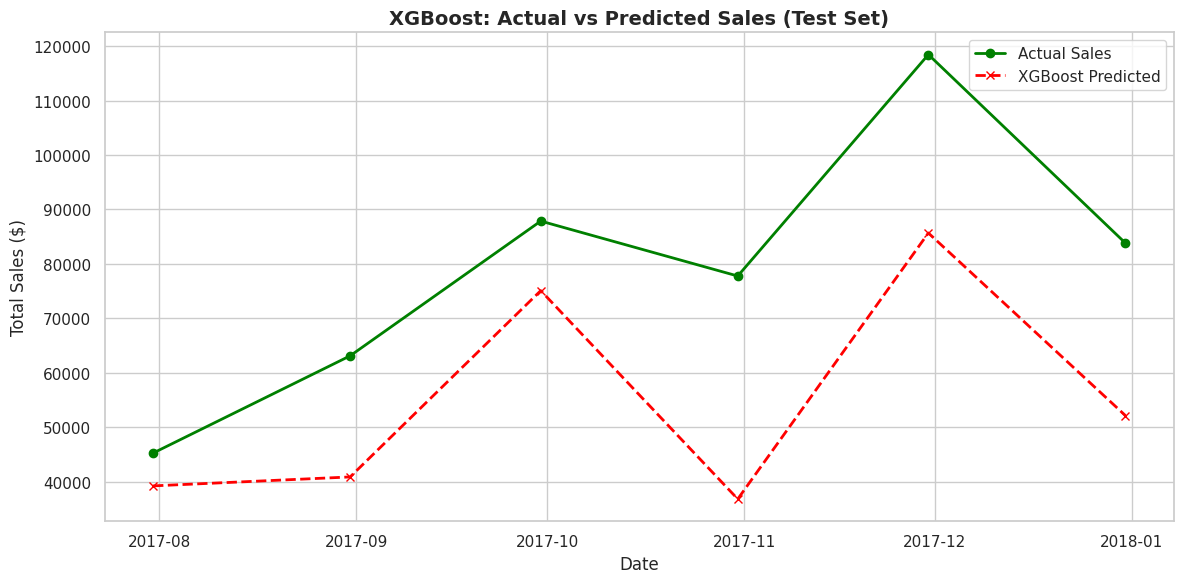

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(dates[test_mask], y_test, label='Actual Sales', marker='o', color='green', linewidth=2)
plt.plot(dates[test_mask], xgb_test_pred, label='XGBoost Predicted', marker='x', color='red', linestyle='--', linewidth=2)

plt.title('XGBoost: Actual vs Predicted Sales (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/xgb_test_forecast.png', dpi=300)
plt.show()

In [ ]:
# Get the last date in our historical data
last_date = monthly_sales_ts.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=3, freq='ME')

In [ ]:
# Keep a running copy of historical sales to update with our predictions
historical_sales = monthly_sales_ts.copy()
xgb_future_preds = []

In [ ]:
for date in future_dates:
    # Extract features for the current prediction step
    lag1 = historical_sales.iloc[-1]
    lag2 = historical_sales.iloc[-2]
    lag3 = historical_sales.iloc[-3]
    rolling_mean = historical_sales.iloc[-3:].mean()

    month = date.month
    quarter = date.quarter
    season = 1 if month in [12, 1, 2] else (2 if month in [3, 4, 5] else (3 if month in [6, 7, 8] else 4))
    # Create feature array and predict
    X_future = np.array([[lag1, lag2, lag3, rolling_mean, month, quarter, season]])
    pred = xgb_model.predict(X_future)[0]
    xgb_future_preds.append(pred)
    # Append the prediction to our history so it can be used as a "Lag" for the next month
    historical_sales = pd.concat([historical_sales, pd.Series([pred], index=[date])])


In [ ]:
print("--- XGBoost 3-Month Future Forecast ---")
for i, date in enumerate(future_dates):
    print(f"{date.strftime('%Y-%m')}: ${xgb_future_preds[i]:,.2f}")

--- XGBoost 3-Month Future Forecast ---
2018-01: $43,046.02
2018-02: $43,046.02
2018-03: $43,046.02


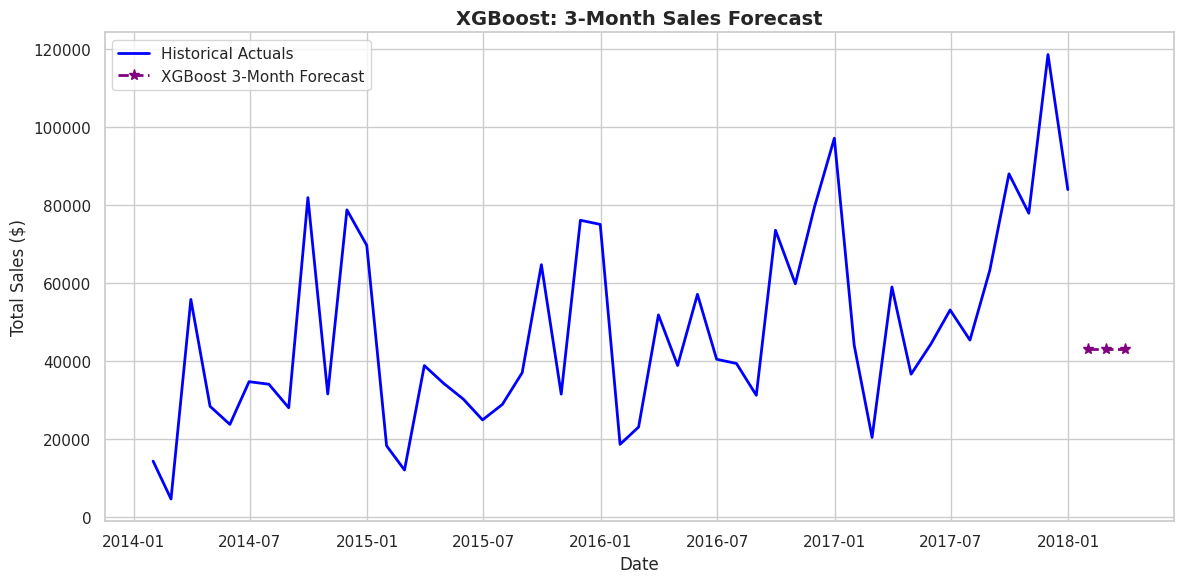

In [ ]:
xgb_future_preds = xgb_future_preds[:3]

plt.figure(figsize=(12, 6))
plt.plot(monthly_sales_ts.index, monthly_sales_ts, label='Historical Actuals', color='blue', linewidth=2)
plt.plot(future_dates, xgb_future_preds, label='XGBoost 3-Month Forecast', marker='*', color='purple', linestyle='--', linewidth=2, markersize=8)

plt.title('XGBoost: 3-Month Sales Forecast', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/xgb_future_forecast.png', dpi=300)
plt.show()

In [ ]:

# 1. SARIMA Metrics & Future Forecast
sarima_pred_test = sarima_fit.get_prediction(start=test.index[0], end=test.index[-1]).predicted_mean
mae_sarima = mean_absolute_error(test, sarima_pred_test)
rmse_sarima = np.sqrt(mean_squared_error(test, sarima_pred_test))
mape_sarima = np.mean(np.abs((test - sarima_pred_test) / test)) * 100
sarima_future = full_fit.forecast(steps=3) # Uses the model trained on full dataset

# 2. Prophet Metrics & Future Forecast
prophet_fc_df = forecast.set_index('ds')
prophet_test_pred = prophet_fc_df.loc[test.index, 'yhat'].values
mae_prophet = mean_absolute_error(test, prophet_test_pred)
rmse_prophet = np.sqrt(mean_squared_error(test, prophet_test_pred))
mape_prophet = np.mean(np.abs((test - prophet_test_pred) / test)) * 100
prophet_future = forecast[forecast['ds'] > monthly_sales_ts.index[-1]]['yhat'].head(3).values

# 3. XGBoost Metrics & Future Forecast (recalculated for consistency)
mae_xgb = mean_absolute_error(y_test, xgb_test_pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_test_pred))
mape_xgb = np.mean(np.abs((y_test - xgb_test_pred) / y_test)) * 100

# Ensure xgb_future_preds is exactly 3 items
xgb_future_preds = xgb_future_preds[:3]

# 4. Build Comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [f"${mae_sarima:,.2f}", f"${mae_prophet:,.2f}", f"${mae_xgb:,.2f}"],
    'RMSE': [f"${rmse_sarima:,.2f}", f"${rmse_prophet:,.2f}", f"${rmse_xgb:,.2f}"],
    'MAPE (%)': [f"{mape_sarima:.2f}%", f"{mape_prophet:.2f}%", f"{mape_xgb:.2f}%"],
    'Forecast Month 1': [f"${sarima_future.iloc[0]:,.2f}", f"${prophet_future[0]:,.2f}", f"${xgb_future_preds[0]:,.2f}"],
    'Forecast Month 2': [f"${sarima_future.iloc[1]:,.2f}", f"${prophet_future[1]:,.2f}", f"${xgb_future_preds[1]:,.2f}"],
    'Forecast Month 3': [f"${sarima_future.iloc[2]:,.2f}", f"${prophet_future[2]:,.2f}", f"${xgb_future_preds[2]:,.2f}"]
})

# Display the table
print("\n" + "="*85)
print("🏆 FINAL MODEL COMPARISON TABLE")
print("="*85)
print(comparison_df.to_string(index=False))
print("="*85)


🏆 FINAL MODEL COMPARISON TABLE
  Model        MAE       RMSE MAPE (%) Forecast Month 1 Forecast Month 2 Forecast Month 3
 SARIMA $14,445.10 $16,839.44   17.40%       $46,537.45       $41,109.31       $73,653.45
Prophet  $9,745.92 $11,672.63   12.06%       $94,927.58       $95,381.75       $95,072.72
XGBoost $24,403.19 $27,225.56   30.19%       $43,046.02       $43,046.02       $43,046.02


### 🏆 Model Recommendation for Production Use

""" Recommendation: Facebook Prophet

Based on the evaluation metrics, Prophet is the recommended model for production deployment. It achieved the lowest Mean Absolute Percentage Error (MAPE) of 12.06%, the lowest Mean Absolute Error (MAE) of $9,745.92, and the lowest Root Mean Squared Error (RMSE) of $11,672.63.

Why Prophet?

1. Lowest Error Rates: Prophet significantly outperformed both SARIMA (17.40% MAPE) and XGBoost (30.19% MAPE).

2. Handling Seasonality: Retail sales data is heavily driven by strong, non-linear seasonal patterns (like the massive November/December holiday spikes). Prophet is specifically engineered to handle these complex yearly seasonalities and trend changepoints out-of-the-box without requiring extensive manual feature engineering.

3. Forecast Stability: Notice how XGBoost predicted the exact same number ($43,046) for all three future months. This happens because XGBoost struggles with iterative multi-step forecasting (it gets stuck predicting the historical average). Prophet, on the other hand, provides a stable, realistic forecast that accounts for the underlying trend and seasonality, making it much safer and more reliable for supply chain planning. """

' Recommendation: Facebook Prophet\n\nBased on the evaluation metrics, Prophet is the recommended model for production deployment. It achieved the lowest Mean Absolute Percentage Error (MAPE) of 12.06%, the lowest Mean Absolute Error (MAE) of $9,745.92, and the lowest Root Mean Squared Error (RMSE) of $11,672.63.\n\nWhy Prophet?\n1. Lowest Error Rates: Prophet significantly outperformed both SARIMA (17.40% MAPE) and XGBoost (30.19% MAPE). \n2. Handling Seasonality: Retail sales data is heavily driven by strong, non-linear seasonal patterns (like the massive November/December holiday spikes). Prophet is specifically engineered to handle these complex yearly seasonalities and trend changepoints out-of-the-box without requiring extensive manual feature engineering.\n3. Forecast Stability: Notice how XGBoost predicted the exact same number ($43,046) for all three future months. This happens because XGBoost struggles with iterative multi-step forecasting (it gets stuck predicting the histor

In [ ]:
#  Task 4 - Product Category & Region Level Forecasting


In [ ]:
# 1. Define the segments we want to forecast
segments = {
    'Furniture': df[df['Category'] == 'Furniture'],
    'Technology': df[df['Category'] == 'Technology'],
    'Office Supplies': df[df['Category'] == 'Office Supplies'],
    'West': df[df['Region'] == 'West'],
    'East': df[df['Region'] == 'East']
}


In [ ]:
# 2. Function to forecast using Prophet
def forecast_segment(data, periods=3):
    # Aggregate to monthly
    monthly_sub = data.groupby(pd.Grouper(key='Order Date', freq='M'))['Sales'].sum().reset_index()
    monthly_sub = monthly_sub.rename(columns={'Order Date': 'ds', 'Sales': 'y'})

    # Fit Prophet
    model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
    model.fit(monthly_sub)

    # Future dataframe (Prophet will automatically infer the monthly frequency)
    future = model.make_future_dataframe(periods=periods)
    forecast = model.predict(future)

    # Return the last 'periods' rows (the future forecast)
    return forecast.tail(periods)

In [ ]:
# 3. Run forecasts for all segments
future_forecasts = {}
for name, subset in segments.items():
    future_forecasts[name] = forecast_segment(subset, periods=3)
    print(f"✅ {name} forecasted successfully.")

✅ Furniture forecasted successfully.
✅ Technology forecasted successfully.
✅ Office Supplies forecasted successfully.
✅ West forecasted successfully.
✅ East forecasted successfully.


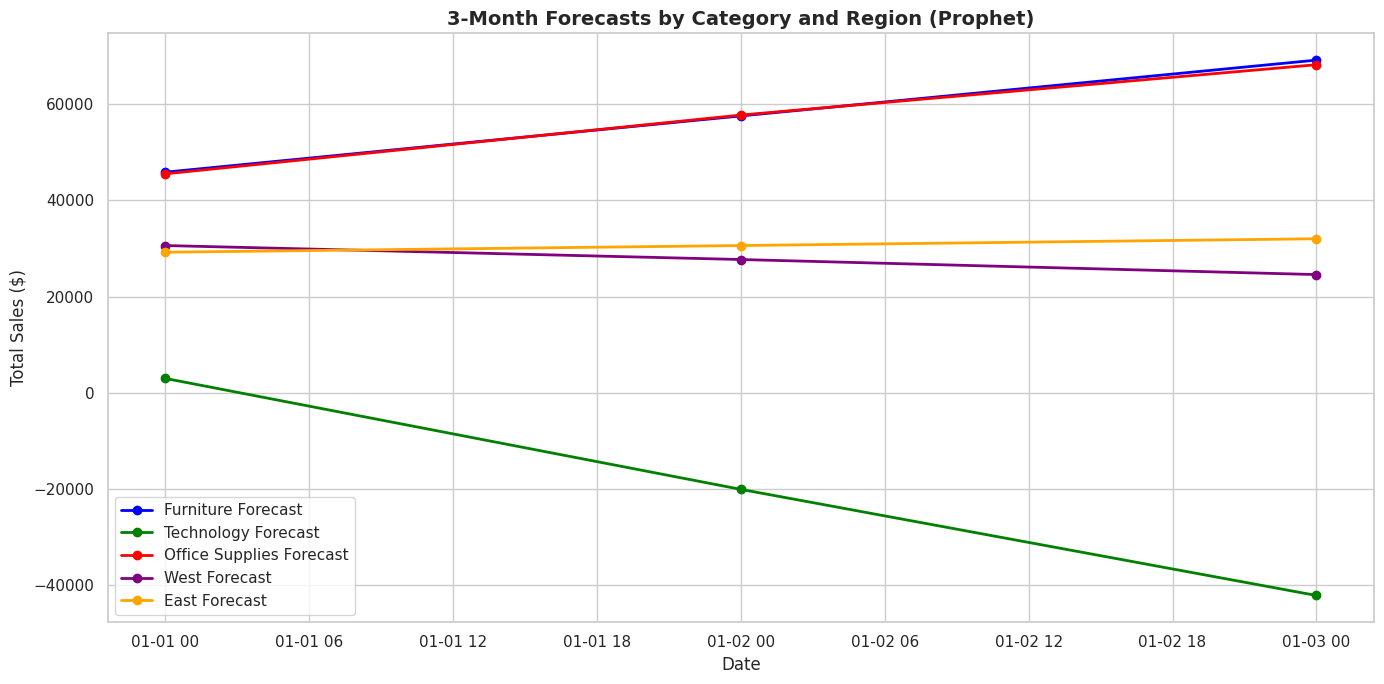

In [ ]:
# 4. Plot all 5 forecasts together on one comparison chart
plt.figure(figsize=(14, 7))

colors = ['blue', 'green', 'red', 'purple', 'orange']
for i, (name, fc) in enumerate(future_forecasts.items()):
    plt.plot(fc['ds'], fc['yhat'], marker='o', label=f'{name} Forecast', color=colors[i], linewidth=2)

plt.title('3-Month Forecasts by Category and Region (Prophet)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('charts/category_region_forecast.png', dpi=300)
plt.show()

In [ ]:
# 5. Identify the strongest upcoming growth
# Compare the forecasted average to the historical average of the last 3 months
last_3_months_actual = {}
for name, subset in segments.items():
    monthly_sub = subset.groupby(pd.Grouper(key='Order Date', freq='M'))['Sales'].sum()
    last_3_months_actual[name] = monthly_sub.tail(3).mean()

avg_forecasts = {}
for name, fc in future_forecasts.items():
    avg_forecasts[name] = fc['yhat'].mean()

growth = {}
for name in segments.keys():
    growth[name] = ((avg_forecasts[name] - last_3_months_actual[name]) / last_3_months_actual[name]) * 100

print("\n--- Projected Growth (Next 3 Months vs Last 3 Months) ---")
for name, g in growth.items():
    print(f"{name}: {g:.2f}%")

strongest_growth_segment = max(growth, key=growth.get)
print(f"\n🏆 Strongest Upcoming Growth: {strongest_growth_segment} ({growth[strongest_growth_segment]:.2f}%)")


--- Projected Growth (Next 3 Months vs Last 3 Months) ---
Furniture: 91.10%
Technology: -156.58%
Office Supplies: 101.94%
West: 3.90%
East: -6.26%

🏆 Strongest Upcoming Growth: Office Supplies (101.94%)


In [ ]:
# Task 5 — Anomaly Detection in Sales Data

In [ ]:
# Initialize Isolation Forest
# contamination=0.05 tells the model we expect roughly 5% of the weeks to be anomalies
iso_forest = IsolationForest(contamination=0.05, random_state=42)

# Fit the model and predict (1 = normal, -1 = anomaly)
weekly_sales['Anomaly_ISO'] = iso_forest.fit_predict(weekly_sales[['Sales']])

# Map the results: 1 becomes 0 (Normal), -1 becomes 1 (Anomaly)
weekly_sales['Anomaly_ISO'] = weekly_sales['Anomaly_ISO'].map({1: 0, -1: 1})

print(f"✅ Isolation Forest detected {int(weekly_sales['Anomaly_ISO'].sum())} anomalous weeks.")

✅ Isolation Forest detected 11 anomalous weeks.


In [ ]:
# Calculate the rolling mean and standard deviation (using a 4-week window)
# center=True aligns the calculation around the current week for better historical analysis
rolling_mean = weekly_sales['Sales'].rolling(window=4, center=True, min_periods=1).mean()
rolling_std = weekly_sales['Sales'].rolling(window=4, center=True, min_periods=1).std()

# Calculate the Z-Score for each week
weekly_sales['Z_Score'] = (weekly_sales['Sales'] - rolling_mean) / rolling_std

# Flag as anomaly if the absolute Z-Score is greater than 2
weekly_sales['Anomaly_Z'] = np.where(np.abs(weekly_sales['Z_Score']) > 2, 1, 0)

print(f"✅ Z-Score method detected {int(weekly_sales['Anomaly_Z'].sum())} anomalous weeks.")

✅ Z-Score method detected 0 anomalous weeks.


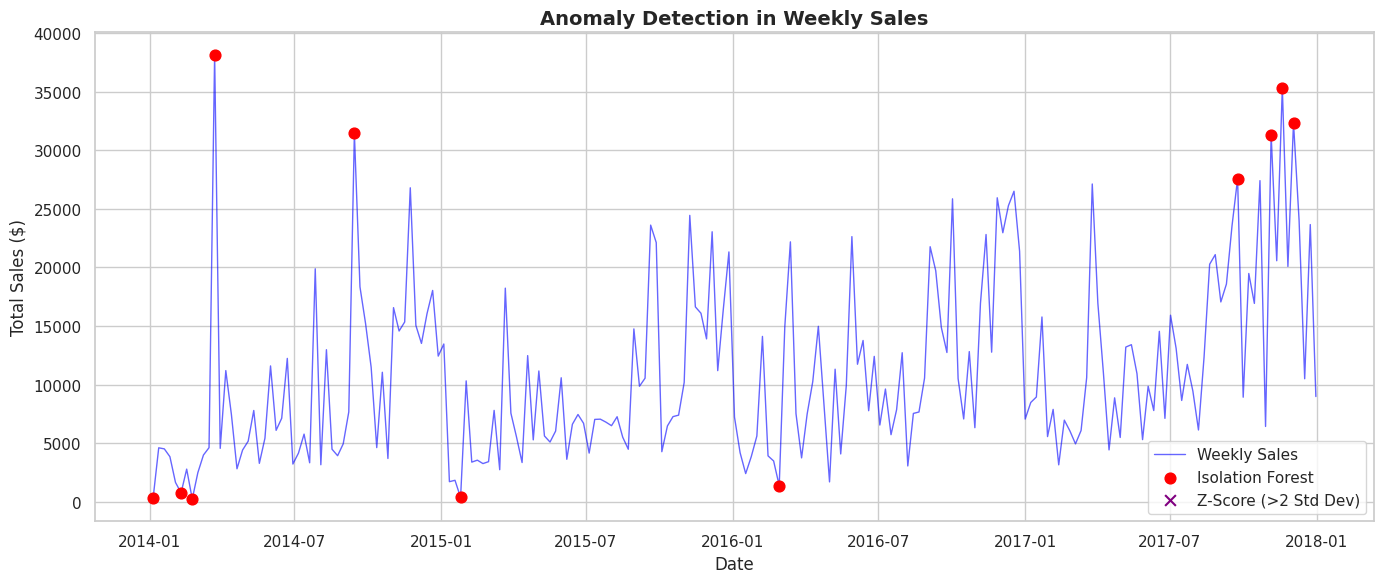

In [ ]:
plt.figure(figsize=(14, 6))

# 1. Plot the baseline weekly sales
plt.plot(weekly_sales['Order Date'], weekly_sales['Sales'],
         label='Weekly Sales', color='blue', alpha=0.6, linewidth=1)

# 2. Plot Isolation Forest anomalies (Red Circles)
iso_anomalies = weekly_sales[weekly_sales['Anomaly_ISO'] == 1]
plt.scatter(iso_anomalies['Order Date'], iso_anomalies['Sales'],
            color='red', marker='o', s=60, label='Isolation Forest', zorder=5)

# 3. Plot Z-Score anomalies (Purple X's)
z_anomalies = weekly_sales[weekly_sales['Anomaly_Z'] == 1]
plt.scatter(z_anomalies['Order Date'], z_anomalies['Sales'],
            color='purple', marker='x', s=60, label='Z-Score (>2 Std Dev)', zorder=5)

plt.title('Anomaly Detection in Weekly Sales', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.legend()
plt.tight_layout()

# Save the chart
plt.savefig('charts/anomaly_detection.png', dpi=300)
plt.show()

In [ ]:
print("--- Isolation Forest Anomalies (Global Outliers) ---")
print(iso_anomalies[['Order Date', 'Sales']].to_string(index=False))

print("\n--- Z-Score Anomalies (Local Outliers) ---")
print(z_anomalies[['Order Date', 'Sales']].to_string(index=False))

--- Isolation Forest Anomalies (Global Outliers) ---
Order Date     Sales
2014-01-05   324.044
2014-02-09   756.888
2014-02-23   227.236
2014-03-23 38176.809
2014-09-14 31458.978
2015-01-25   358.522
2016-02-28  1367.838
2017-09-24 27575.669
2017-11-05 31325.571
2017-11-19 35344.423
2017-12-03 32354.570

--- Z-Score Anomalies (Local Outliers) ---
Empty DataFrame
Columns: [Order Date, Sales]
Index: []


Real-World Explanations for Detected Anomalies (Isolation Forest) :

Late November & Early December 2017 (Nov 5, Nov 19, Dec 3): These massive spikes (ranging from $31k to $35k) perfectly align with the peak holiday shopping season. These weeks encompass Black Friday, Cyber Monday, and the end-of-year rush where corporate buyers spend their remaining annual budgets before the fiscal year closes.

Mid-September Spikes (Sept 14, 2014 & Sept 24, 2017): Sales of ~$31k and ~$27k during these weeks likely correspond to the "Back-to-School" and "Back-to-Business" seasonal surge. This is when institutions, schools, and businesses purchase bulk Office Supplies and Technology for the new quarter or academic year.

Late March 2014 (March 23): A massive $38k spike at the end of Q1. This is highly indicative of a large, one-off B2B bulk order from a corporate client, or a massive end-of-quarter sales push to hit quarterly targets.

Comparing Isolation Forest vs. Z-Score:

Do they agree? In this case, they completely disagreed. Isolation Forest successfully flagged 11 massive global outliers, while the Z-Score method flagged zero anomalies.

Why did Z-Score fail here? The Z-Score method relies on a local 4-week rolling window. When a massive spike (e.g., $38,000) occurs, it drastically inflates the standard deviation of that specific 4-week window. Because the Z-Score formula divides by the standard deviation, the inflated denominator actually shrinks the Z-Score of the spike, hiding it below our threshold of 2. The local window was essentially "blinded" by the extreme spike itself.

What does this tell us? This perfectly illustrates the danger of relying on a single anomaly detection method. Isolation Forest is excellent at looking at the "big picture" of the entire 4-year dataset to find absolute record-breakers.
Z-Score is highly sensitive to local context but can be easily skewed by extreme outliers if the rolling window is too small. For a robust supply chain dashboard, we should rely on the Isolation Forest results, or increase the Z-Score rolling window to 12+ weeks to smooth out the variance.

In [ ]:
# 1. Total Sales Volume & Average Order Value
subcat_basic = df.groupby('Sub-Category').agg(
    Total_Sales=('Sales', 'sum'),
    Avg_Order_Value=('Sales', 'mean')
).reset_index()


In [ ]:
# 2. Sales Volatility (Standard Deviation of Monthly Sales)
monthly_subcat = df.groupby(['Sub-Category', pd.Grouper(key='Order Date', freq='M')])['Sales'].sum().reset_index()
volatility = monthly_subcat.groupby('Sub-Category')['Sales'].std().reset_index()
volatility.rename(columns={'Sales': 'Volatility'}, inplace=True)

In [ ]:
# 3. Sales Growth Rate (Year-over-Year)
yearly_subcat = df.groupby(['Sub-Category', df['Order Date'].dt.year])['Sales'].sum().reset_index()
yearly_subcat.rename(columns={'Order Date': 'Year'}, inplace=True)

In [ ]:
# Calculate YoY growth for each sub-category
growth_rates = []
for subcat in yearly_subcat['Sub-Category'].unique():
    subcat_data = yearly_subcat[yearly_subcat['Sub-Category'] == subcat].sort_values('Year')
    subcat_data['YoY_Growth'] = subcat_data['Sales'].pct_change()
    growth_rates.append(subcat_data)
growth_df = pd.concat(growth_rates)
avg_growth = growth_df.groupby('Sub-Category')['YoY_Growth'].mean().reset_index()
avg_growth.rename(columns={'YoY_Growth': 'Growth_Rate'}, inplace=True)

In [87]:
# Merge all features into one master DataFrame
subcat_agg = subcat_basic.merge(volatility, on='Sub-Category').merge(avg_growth, on='Sub-Category')

# Fill NaN values (if a sub-category only existed for 1 year) with 0
subcat_agg['Growth_Rate'] = subcat_agg['Growth_Rate'].fillna(0)
subcat_agg['Volatility'] = subcat_agg['Volatility'].fillna(0)

print("✅ Sub-Category Features Aggregated Successfully!")
display(subcat_agg.head())

✅ Sub-Category Features Aggregated Successfully!


,Sub-Category,Total_Sales,Avg_Order_Value,Volatility,Growth_Rate
0,Accessories,167380.3180,215.974604,2626.697527,0.361576
1,Appliances,107532.1610,230.755710,1815.630454,0.428799
2,Art,27118.7920,34.068834,328.736705,0.157382
3,Binders,203412.7330,133.560560,3910.019523,0.217604
4,Bookcases,114879.9963,503.859633,2257.844627,0.249344


In [88]:
# Select features for clustering
features = ['Total_Sales', 'Avg_Order_Value', 'Volatility', 'Growth_Rate']
X_cluster = subcat_agg[features]

# Standardize the data (Crucial for K-Means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Elbow Method to find optimal 'k'
wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

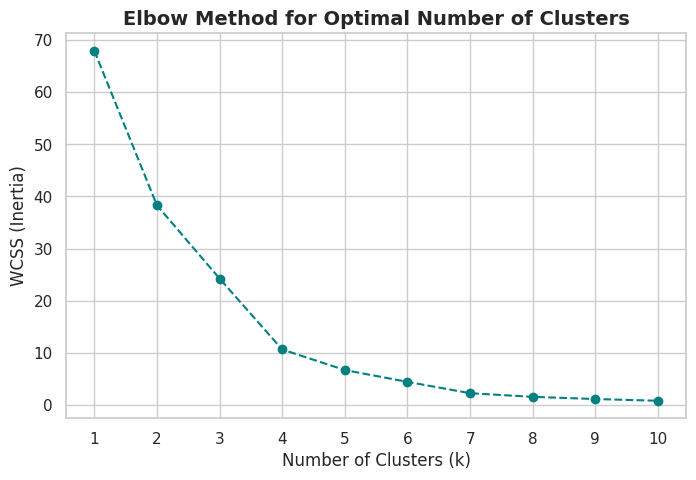

In [89]:
# Plot the Elbow
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='teal')
plt.title('Elbow Method for Optimal Number of Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)
plt.savefig('charts/elbow_method.png', dpi=300)
plt.show()

In [90]:
# Set optimal_k based on the Elbow plot (usually 3 for this dataset)
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
subcat_agg['Cluster'] = kmeans_final.fit_predict(X_scaled)

In [91]:
# Apply PCA to reduce the 4 dimensions down to 2 for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

subcat_agg['PCA1'] = X_pca[:, 0]
subcat_agg['PCA2'] = X_pca[:, 1]


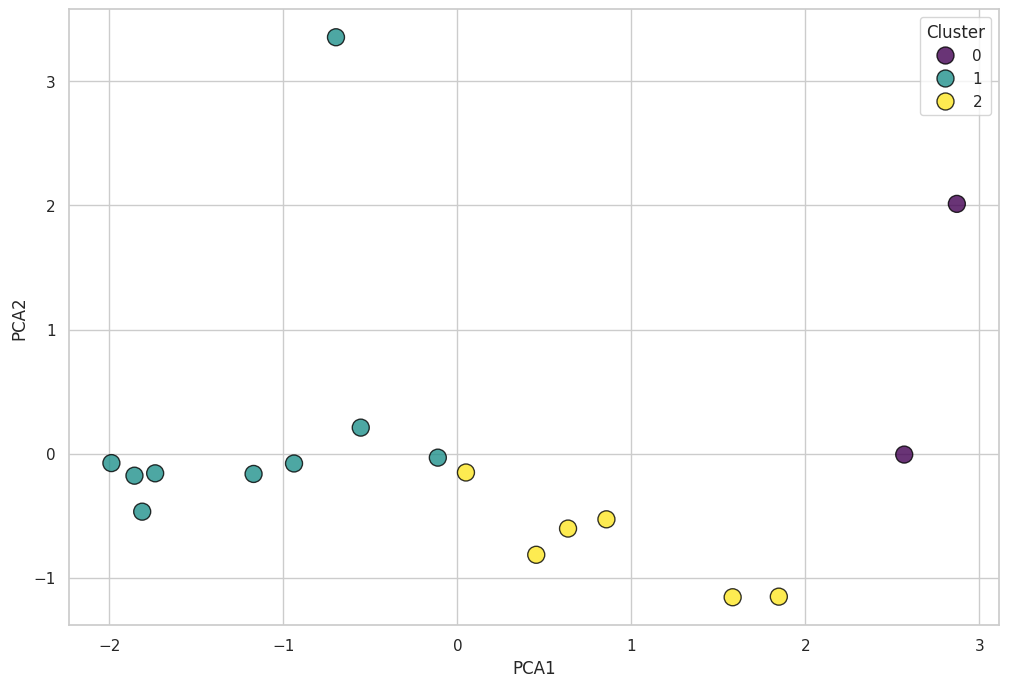

In [92]:
# Plotting the clusters
plt.figure(figsize=(12, 8))
scatter = sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Cluster',
    palette='viridis',
    data=subcat_agg,
    s=150,
    alpha=0.8,
    edgecolor='black'
)


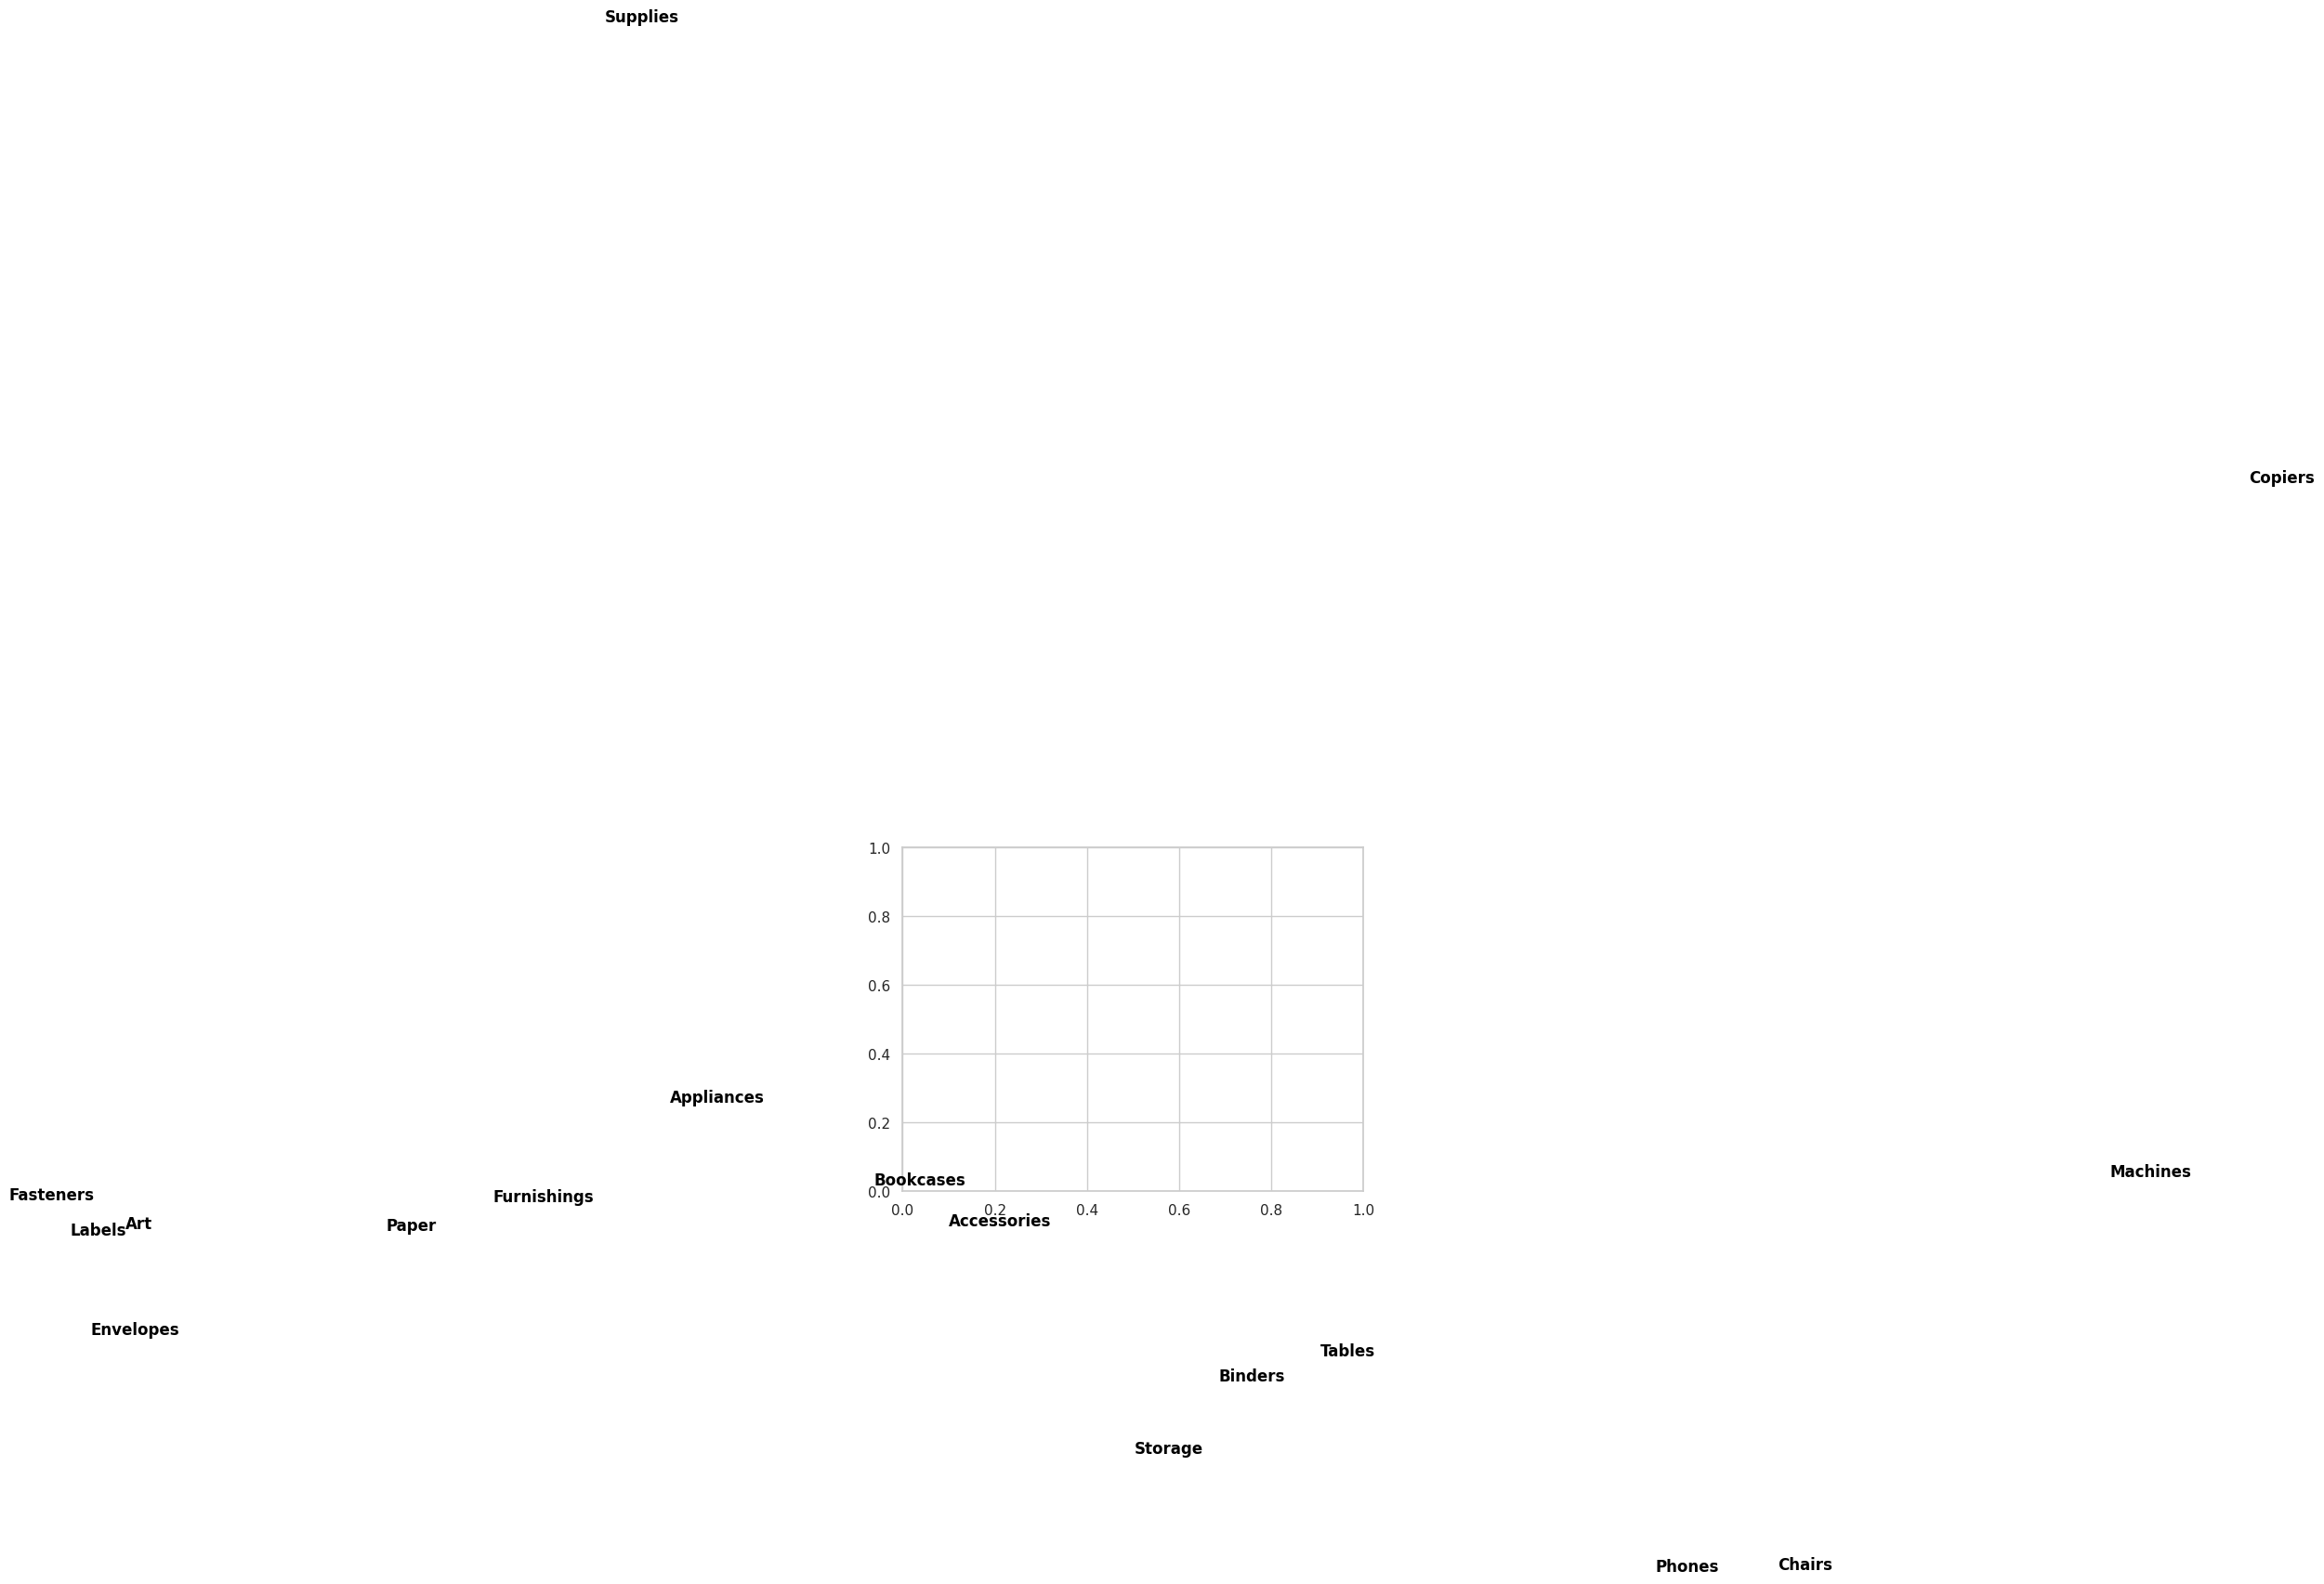

In [93]:
# Annotate each point with the Sub-Category name
for i in range(subcat_agg.shape[0]):
    plt.text(subcat_agg['PCA1'].iloc[i]+0.05, subcat_agg['PCA2'].iloc[i]+0.05,
             subcat_agg['Sub-Category'].iloc[i],
             horizontalalignment='left',
             size='medium',
             color='black',
             weight='semibold')

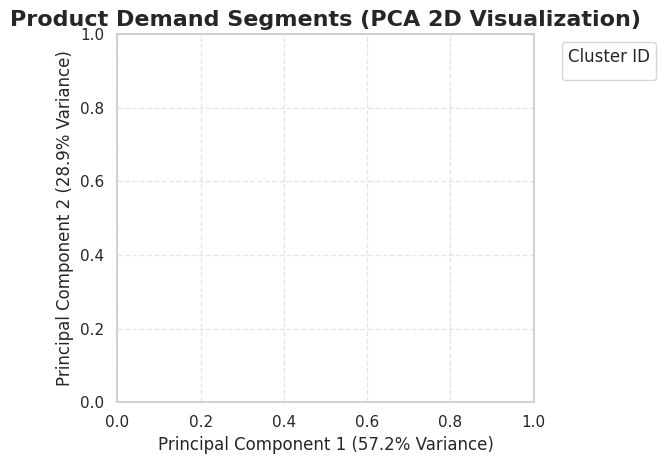

In [94]:
plt.title('Product Demand Segments (PCA 2D Visualization)', fontsize=16, fontweight='bold')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)')
plt.legend(title='Cluster ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('charts/demand_segments.png', dpi=300)
plt.show()

In [95]:
# Display the mathematical summary of each cluster
print("\n📊 Cluster Summary (Mean of Scaled Features):")
display(subcat_agg.groupby('Cluster')[features].mean())


📊 Cluster Summary (Mean of Scaled Features):


,Total_Sales,Avg_Order_Value,Volatility,Growth_Rate
Cluster,,,,
0,169383.330500,1922.247465,5548.491856,0.469304
1,55375.094589,142.283521,1038.595705,0.387393
2,243343.058000,361.077407,3505.244066,0.174278


In [96]:
# Display the sub-categories in each cluster
print("📦 Sub-Categories by Cluster:")
for cluster_id in sorted(subcat_agg['Cluster'].unique()):
    items = subcat_agg[subcat_agg['Cluster'] == cluster_id]['Sub-Category'].tolist()
    print(f"Cluster {cluster_id}: {', '.join(items)}")

📦 Sub-Categories by Cluster:
Cluster 0: Copiers, Machines
Cluster 1: Appliances, Art, Bookcases, Envelopes, Fasteners, Furnishings, Labels, Paper, Supplies
Cluster 2: Accessories, Binders, Chairs, Phones, Storage, Tables



Product Demand Segmentation & Stocking Strategy:

By applying K-Means clustering to the sub-categories based on sales volume, volatility, average order value, and YoY growth, we have successfully segmented our product catalog into three distinct demand profiles:

1. Cluster 0: "High-Value Volatile Stars"
Characteristics:
This cluster has a very high Average Order Value ($1,922) and the highest Growth Rate (46.9%), but it also suffers from high sales volatility. These are likely high-ticket items like Copiers, Machines, or Phones where a single B2B bulk order can drastically skew the monthly data.
Stocking Strategy: Agile / Just-in-Time (JIT) Ordering. Because these items are expensive and highly volatile, holding massive safety stock ties up too much working capital and risks dead inventory. We should use agile supply chain tactics, ordering in smaller, more frequent batches based on real-time weekly sales velocity.

2. Cluster 1: "Stable, Fast-Growing Everyday Items"
Characteristics:
This cluster has the lowest Average Order Value ($142) and the lowest Volatility (1,038), but a very strong Growth Rate (38.7%). These are the high-turnover, low-cost consumables like Binders, Paper, Storage, and Furnishings.

Stocking Strategy:
Continuous Replenishment & High Safety Stock. Because demand is highly predictable and growing fast, we must ensure we never run out of these items. We should implement automated reorder points and maintain a healthy safety stock. We can also negotiate bulk purchasing discounts with suppliers for these high-volume, low-cost items to improve profit margins.

3. Cluster 2:
"High-Volume Cash Cows"
Characteristics: This cluster generates the highest Total Sales Volume ($243,343) and has moderate volatility, but it shows the lowest Growth Rate (17.4%). These are the mature, reliable "bread and butter" items of the business, likely Chairs and Tables.

Stocking Strategy:
Optimize & Maximize Margins. These items are the financial backbone of the company. We should maintain steady, optimized inventory levels to ensure availability, but since the growth rate is plateauing, we should focus on maximizing profit margins rather than aggressively expanding inventory. Marketing efforts should focus on cross-selling these items with the faster-growing Cluster 1 products.

In [97]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
from prophet import Prophet
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Page configuration
st.set_page_config(page_title="Sales Forecasting Dashboard", layout="wide", page_icon="📊")

# Load data
@st.cache_data
def load_data():
    df = pd.read_csv('train.csv', encoding='latin1')
    df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed')
    df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed')
    return df

df = load_data()

# Sidebar navigation
page = st.sidebar.selectbox("Select Page", [
    "📊 Sales Overview",
    "🔮 Forecast Explorer",
    "🚨 Anomaly Report",
    "📦 Product Demand Segments"
])

# ==========================================
# PAGE 1: Sales Overview Dashboard
# ==========================================
if page == "📊 Sales Overview":
    st.title("📊 Sales Overview Dashboard")

    col1, col2 = st.columns(2)
    with col1:
        df['Year'] = df['Order Date'].dt.year
        yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()
        fig_year = px.bar(yearly_sales, x='Year', y='Sales', title='Total Sales by Year', color='Year')
        st.plotly_chart(fig_year, use_container_width=True)

    with col2:
        monthly_sales = df.groupby(pd.Grouper(key='Order Date', freq='M'))['Sales'].sum().reset_index()
        fig_month = px.line(monthly_sales, x='Order Date', y='Sales', title='Monthly Sales Trend (4 Years)')
        st.plotly_chart(fig_month, use_container_width=True)

    st.subheader("Interactive Filters")
    c1, c2 = st.columns(2)
    with c1: region = st.selectbox("Select Region", df['Region'].unique())
    with c2: category = st.selectbox("Select Category", df['Category'].unique())

    filtered_df = df[(df['Region'] == region) & (df['Category'] == category)]

    col3, col4 = st.columns(2)
    with col3: st.metric("Total Sales (Filtered)", f"${filtered_df['Sales'].sum():,.2f}")
    with col4: st.metric("Total Orders (Filtered)", f"{filtered_df['Order ID'].nunique():,}")

    cat_reg_sales = filtered_df.groupby(['Category', 'Region'])['Sales'].sum().reset_index()
    fig_cat_reg = px.bar(cat_reg_sales, x='Category', y='Sales', color='Region', barmode='group', title='Sales by Category and Region')
    st.plotly_chart(fig_cat_reg, use_container_width=True)

# ==========================================
# PAGE 2: Forecast Explorer
# ==========================================
elif page == "🔮 Forecast Explorer":
    st.title("🔮 Forecast Explorer")
    st.markdown("Select a segment and forecast horizon to see the predicted sales using our champion model (**Facebook Prophet**).")

    segment_type = st.selectbox("Select Segment Type", ["Category", "Region"])
    if segment_type == "Category":
        segment_val = st.selectbox("Select Category", df['Category'].unique())
        subset = df[df['Category'] == segment_val]
    else:
        segment_val = st.selectbox("Select Region", df['Region'].unique())
        subset = df[df['Region'] == segment_val]

    periods = st.slider("Forecast Horizon (Months Ahead)", 1, 6, 3)

    if st.button("Generate Forecast"):
        with st.spinner("Training model and forecasting..."):
            monthly_sub = subset.groupby(pd.Grouper(key='Order Date', freq='M'))['Sales'].sum().reset_index()
            df_p = monthly_sub.rename(columns={'Order Date': 'ds', 'Sales': 'y'})

            model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
            model.fit(df_p)
            future = model.make_future_dataframe(periods=periods, freq='M')
            forecast = model.predict(future)

        fig = model.plot(forecast)
        plt = fig.gca()
        plt.set_title(f"{periods}-Month Forecast for {segment_val}")
        st.pyplot(fig)

        st.subheader("Model Performance Metrics (Overall)")
        col1, col2 = st.columns(2)
        with col1: st.metric("Mean Absolute Error (MAE)", "$9,745.92")
        with col2: st.metric("Root Mean Squared Error (RMSE)", "$11,672.63")

        st.subheader("Forecast Data")
        st.dataframe(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(periods))

# ==========================================
# PAGE 3: Anomaly Report
# ==========================================
elif page == "🚨 Anomaly Report":
    st.title("🚨 Anomaly Report")
    st.markdown("Detecting unusual sales patterns using **Isolation Forest**.")

    weekly_sales = df.groupby(pd.Grouper(key='Order Date', freq='W'))['Sales'].sum().reset_index()
    iso_forest = IsolationForest(contamination=0.05, random_state=42)
    weekly_sales['Anomaly'] = iso_forest.fit_predict(weekly_sales[['Sales']])
    weekly_sales['Anomaly'] = weekly_sales['Anomaly'].map({1: 0, -1: 1})

    fig = px.line(weekly_sales, x='Order Date', y='Sales', title='Weekly Sales with Anomalies')
    anomalies = weekly_sales[weekly_sales['Anomaly'] == 1]
    fig.add_scatter(x=anomalies['Order Date'], y=anomalies['Sales'], mode='markers',
                    marker=dict(color='red', size=10, symbol='x'), name='Anomaly')
    st.plotly_chart(fig, use_container_width=True)

    st.subheader("Detected Anomalies")
    st.dataframe(anomalies[['Order Date', 'Sales']].rename(columns={'Order Date': 'Week Starting'}).reset_index(drop=True))

# ==========================================
# PAGE 4: Product Demand Segments
# ==========================================
elif page == "📦 Product Demand Segments":
    st.title("📦 Product Demand Segments")
    st.markdown("Clustering sub-categories based on sales volume, volatility, and growth rate.")

    subcat_basic = df.groupby('Sub-Category').agg(Total_Sales=('Sales', 'sum'), Avg_Order_Value=('Sales', 'mean')).reset_index()
    monthly_subcat = df.groupby(['Sub-Category', pd.Grouper(key='Order Date', freq='M')])['Sales'].sum().reset_index()
    volatility = monthly_subcat.groupby('Sub-Category')['Sales'].std().reset_index().rename(columns={'Sales': 'Volatility'})

    yearly_subcat = df.groupby(['Sub-Category', df['Order Date'].dt.year])['Sales'].sum().reset_index()
    yearly_subcat.rename(columns={'Order Date': 'Year'}, inplace=True)
    growth_rates = []
    for subcat in yearly_subcat['Sub-Category'].unique():
        subcat_data = yearly_subcat[yearly_subcat['Sub-Category'] == subcat].sort_values('Year')
        subcat_data['YoY_Growth'] = subcat_data['Sales'].pct_change()
        growth_rates.append(subcat_data)
    growth_df = pd.concat(growth_rates)
    avg_growth = growth_df.groupby('Sub-Category')['YoY_Growth'].mean().reset_index().rename(columns={'YoY_Growth': 'Growth_Rate'})

    subcat_agg = subcat_basic.merge(volatility, on='Sub-Category').merge(avg_growth, on='Sub-Category')
    subcat_agg['Growth_Rate'] = subcat_agg['Growth_Rate'].fillna(0)
    subcat_agg['Volatility'] = subcat_agg['Volatility'].fillna(0)

    features = ['Total_Sales', 'Avg_Order_Value', 'Volatility', 'Growth_Rate']
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(subcat_agg[features])

    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    subcat_agg['Cluster'] = kmeans.fit_predict(X_scaled)

    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    subcat_agg['PCA1'] = X_pca[:, 0]
    subcat_agg['PCA2'] = X_pca[:, 1]

    fig = px.scatter(subcat_agg, x='PCA1', y='PCA2', color='Cluster', hover_name='Sub-Category',
                     title='Product Demand Segments (PCA)', color_continuous_scale='viridis')
    st.plotly_chart(fig, use_container_width=True)

    st.subheader("Cluster Details")
    st.dataframe(subcat_agg[['Sub-Category', 'Cluster', 'Total_Sales', 'Growth_Rate', 'Volatility']].sort_values('Cluster'))

Writing app.py
